# AI Programming Foundations Project

**Name:** Brian Paul Roche  
**Dataset:** Titanic passenger manifest (891 passengers, 12 variables)  
**Source:** https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv

This project builds a reusable data workflow in Python: ingesting a raw tabular dataset,
cleaning it through documented functions, exploring it with a reusable analysis function,
and visualising the results. The Titanic manifest was chosen because it carries genuine,
structurally different kinds of missing data, which makes the cleaning stage a real
engineering decision rather than a formality.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.width', 120)

## 2. Ingestion

In [2]:
df_raw = pd.read_csv('titanic.csv')
df_raw.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print('Rows, columns:', df_raw.shape)
print()
print('Missing values per column:')
print(df_raw.isna().sum()[df_raw.isna().sum() > 0])

Rows, columns: (891, 12)

Missing values per column:
Age         177
Cabin       687
Embarked      2
dtype: int64


## 3. Cleaning

Three distinct missing-data problems appear in this dataset, and each needs a different
treatment. `Age` is missing for 177 passengers but is a usable variable, so it is imputed.
`Cabin` is missing for 687 of 891 — imputing it would be invention, so the *fact* of its
absence is preserved as a feature and the column itself is dropped. `Embarked` is missing
for two rows only, so the mode is a safe fill.

In [4]:
def clean_missing_values(df):
    """
    Handle the three missing-data problems in the Titanic manifest, each on its own terms.

    Age      : imputed with the median age of the passenger's own Pclass and Sex group,
               because age distribution differs sharply between those groups and a single
               global median would flatten a real signal.
    Cabin    : 77% missing. Not imputed. Replaced by a binary 'HasCabin' flag, because a
               recorded cabin is itself informative (it correlates with fare and class)
               while inventing cabin numbers would fabricate data.
    Embarked : 2 rows missing. Filled with the mode, the least distorting choice at that
               volume.

    Returns a new DataFrame; the input is not modified.
    """
    out = df.copy()

    out['Age'] = out.groupby(['Pclass', 'Sex'])['Age'].transform(
        lambda s: s.fillna(s.median())
    )

    out['HasCabin'] = out['Cabin'].notna().astype(int)
    out = out.drop(columns=['Cabin'])

    out['Embarked'] = out['Embarked'].fillna(out['Embarked'].mode()[0])

    return out

In [5]:
def clean_types_and_features(df):
    """
    Correct data types and derive the features the analysis actually needs.

    - Drops PassengerId and Ticket: identifiers with no analytical content.
    - Extracts Title from Name (Mr, Mrs, Miss, Master, Other). Title carries age, sex and
      social status in a single low-cardinality variable, and survives where Age is noisy.
    - Derives FamilySize (siblings/spouses + parents/children + self) and IsAlone, because
      SibSp and Parch are only meaningful in combination.
    - Casts Sex, Embarked, Title and Pclass to category dtype, which is both correct and
      materially cheaper in memory.

    Returns a new DataFrame; the input is not modified.
    """
    out = df.copy()

    out['Title'] = (out['Name']
                    .str.extract(r',\s*([^\.]+)\.', expand=False)
                    .str.strip())
    common = ['Mr', 'Mrs', 'Miss', 'Master']
    out['Title'] = out['Title'].where(out['Title'].isin(common), 'Other')

    out['FamilySize'] = out['SibSp'] + out['Parch'] + 1
    out['IsAlone'] = (out['FamilySize'] == 1).astype(int)

    out = out.drop(columns=['PassengerId', 'Ticket', 'Name'])

    for col in ['Sex', 'Embarked', 'Title']:
        out[col] = out[col].astype('category')
    out['Pclass'] = out['Pclass'].astype('category')

    return out

In [6]:
df = clean_types_and_features(clean_missing_values(df_raw))

print('Shape after cleaning:', df.shape)
print('Remaining missing values:', int(df.isna().sum().sum()))
df.head()

Shape after cleaning: (891, 12)
Remaining missing values: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,Title,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,0,Mr,2,0
1,1,1,female,38.0,1,0,71.2833,C,1,Mrs,2,0
2,1,3,female,26.0,0,0,7.9250,S,0,Miss,1,1
3,1,1,female,35.0,1,0,53.1000,S,1,Mrs,2,0
4,0,3,male,35.0,0,0,8.0500,S,0,Mr,1,1


## 4. Exploratory Analysis

In [7]:
def explore(df, target='Survived', by=None):
    """
    Reusable exploratory summary for a binary-target tabular dataset.

    Returns a dict with three views:
      'numeric'  - describe() over the numeric columns
      'rates'    - mean of the target broken down by each grouping variable, with counts
      'corr'     - correlation matrix of the numeric columns

    Written as a function rather than inline cells so the same summary can be re-run
    unchanged after any change to the cleaning stage.
    """
    if by is None:
        by = [c for c in ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone', 'HasCabin']
              if c in df.columns]

    rates = {}
    for col in by:
        g = df.groupby(col, observed=True)[target].agg(['mean', 'count'])
        g.columns = ['survival_rate', 'n']
        rates[col] = g.sort_values('survival_rate', ascending=False)

    numeric = df.select_dtypes(include=np.number)

    return {'numeric': numeric.describe().T,
            'rates': rates,
            'corr': numeric.corr(numeric_only=True)}

In [8]:
summary = explore(df)

print('NUMERIC SUMMARY')
print(summary['numeric'].round(2))
print()
for col, table in summary['rates'].items():
    print(f'SURVIVAL RATE BY {col.upper()}')
    print(table.round(3))
    print()

NUMERIC SUMMARY
            count   mean    std   min    25%    50%   75%     max
Survived    891.0   0.38   0.49  0.00   0.00   0.00   1.0    1.00
Age         891.0  29.11  13.30  0.42  21.50  26.00  36.0   80.00
SibSp       891.0   0.52   1.10  0.00   0.00   0.00   1.0    8.00
Parch       891.0   0.38   0.81  0.00   0.00   0.00   0.0    6.00
Fare        891.0  32.20  49.69  0.00   7.91  14.45  31.0  512.33
HasCabin    891.0   0.23   0.42  0.00   0.00   0.00   0.0    1.00
FamilySize  891.0   1.90   1.61  1.00   1.00   1.00   2.0   11.00
IsAlone     891.0   0.60   0.49  0.00   0.00   1.00   1.0    1.00

SURVIVAL RATE BY PCLASS
        survival_rate    n
Pclass                    
1               0.630  216
2               0.473  184
3               0.242  491

SURVIVAL RATE BY SEX
        survival_rate    n
Sex                       
female          0.742  314
male            0.189  577

SURVIVAL RATE BY EMBARKED
          survival_rate    n
Embarked                    
C              

## 5. Visualizations

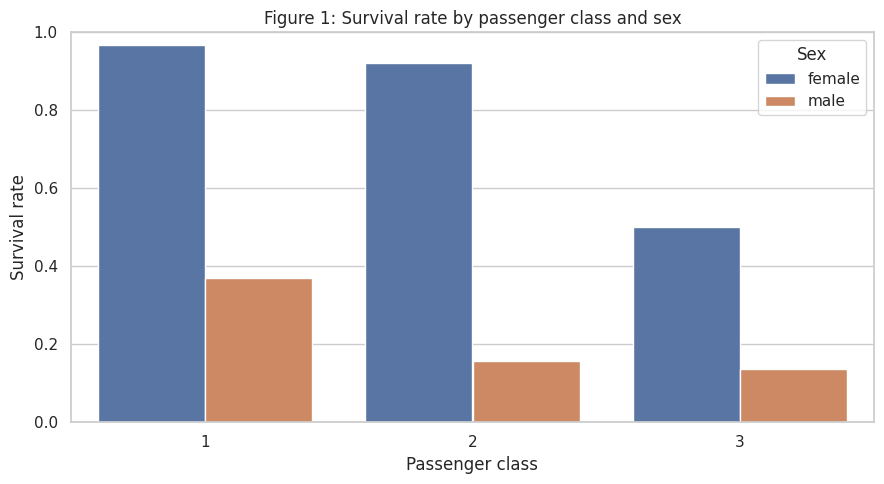

In [9]:
# Figure 1 - survival rate by passenger class and sex

fig, ax = plt.subplots()
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', errorbar=None, ax=ax)
ax.set_title('Figure 1: Survival rate by passenger class and sex')
ax.set_xlabel('Passenger class')
ax.set_ylabel('Survival rate')
ax.set_ylim(0, 1)
ax.legend(title='Sex')
plt.tight_layout()
plt.show()

**Figure 1 — interpretation.** Class and sex do not act independently. Female survival runs
above 90% in first and second class but falls to roughly half in third, while male survival
is low in every class and lowest in third. The gap between the best and worst group is close
to the full range of the variable, which makes these two fields the strongest predictors in
the dataset and the ones any later model would be built around.

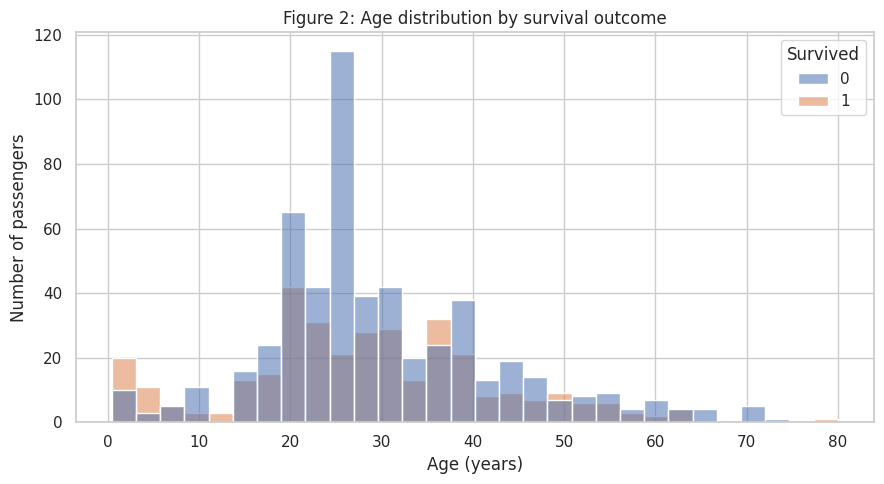

In [10]:
# Figure 2 - age distribution by survival outcome

fig, ax = plt.subplots()
sns.histplot(data=df, x='Age', hue='Survived', bins=30,
             multiple='layer', alpha=0.55, ax=ax)
ax.set_title('Figure 2: Age distribution by survival outcome')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Number of passengers')
plt.tight_layout()
plt.show()

**Figure 2 — interpretation.** The two distributions overlap heavily, so age on its own
separates the outcomes poorly. The one clear exception is the youngest band, where survivors
outnumber non-survivors. The tall bar in the mid-twenties is partly an artefact of the
imputation in `clean_missing_values`: 177 ages were filled with a group median, which
concentrates mass at a handful of values. That is a limitation of the cleaning choice and is
visible in the plot rather than hidden by it.

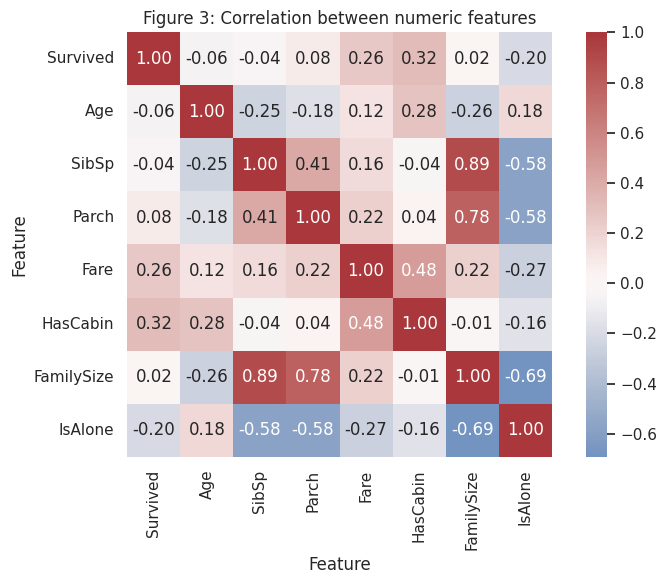

In [11]:
# Figure 3 - correlation between numeric features

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(summary['corr'], annot=True, fmt='.2f', cmap='vlag',
            center=0, square=True, ax=ax)
ax.set_title('Figure 3: Correlation between numeric features')
ax.set_xlabel('Feature')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

**Figure 3 — interpretation.** No numeric pair is strongly correlated, which matters for a
later modelling stage: there is little redundancy to remove. `Fare` and `HasCabin` show the
clearest positive relationship, consistent with both being proxies for wealth. `SibSp` and
`Parch` correlate with `FamilySize` by construction, so only the derived variable should be
carried forward if a model is fitted.

## 6. Summary and Interpretation

**What the dataset shows.** Survival on the Titanic was governed far more by who a passenger
was than by anything about the voyage. Sex and passenger class dominate: a woman in first or
second class was overwhelmingly likely to survive, a man in third class overwhelmingly likely
not to. Family size has a smaller but real effect, with passengers travelling entirely alone
faring worse than those in small family groups.

**Patterns worth noting.** The interaction between class and sex is stronger than either
variable alone, which is why Figure 1 splits on both. The `HasCabin` flag, derived from a
column that was 77% missing, turns out to be informative in its own right — the absence of a
record was itself a signal about the passenger.

**Limitations and assumptions.** Imputing 177 ages with a group median preserves the sample
size but artificially concentrates the age distribution, as Figure 2 shows; any conclusion
resting on age alone should be treated cautiously. Filling `Embarked` with the mode affects
only two rows and is immaterial. Dropping `Cabin`, `Ticket` and `Name` discards information
that a more sophisticated treatment could extract — deck letter from `Cabin`, group travel
from shared `Ticket` values.

**What was unexpected.** That a column missing more than three quarters of its values would
prove useful. The instinct is to drop it outright. Preserving the missingness as a feature
kept a genuine signal that imputation would have destroyed and deletion would have lost.